In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, mean_squared_error, r2_score

In [ ]:
np.random.seed(42)
n = 300
data= pd.DataFrame({
     "age": np.random.randint(18, 60, n),
     "salary": np.random.randint(100000, 200000, n),
     "balance": np.random.randint(0, 100000, n)
})

# Modified churn logic to ensure both 0s and 1s are present
# Churn if balance is low (e.g., < 30000) AND salary is high (e.g., > 170000)
# OR churn if age is high (e.g., > 50)
data["churn"] = (
    (data["balance"] < 30000).astype(int) &
    (data["salary"] > 170000).astype(int)
).astype(int)

# Introduce some additional churn randomly to ensure variability, if the above doesn't create enough
# Alternatively, a simpler condition could be used to guarantee a mix.
# Let's try a condition that is more likely to yield both classes directly:
# Churn if balance is less than 50000 OR if salary is greater than 150000
data["churn"] = ((data["balance"] < 50000) | (data["salary"] > 150000)).astype(int)

data.head()

,age,salary,balance,churn
0,56,139790,88461,0
1,46,105600,9348,1
2,32,194660,23714,1
3,25,193179,38102,1
4,38,140764,74460,0


In [ ]:
print(data.shape)
print(data.info())
print(data.describe())

print(data["churn"].value_counts())

(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
              age         salary       balance       churn
count  300.000000     300.000000    300.000000  300.000000
mean    38.990000  151374.156667  47122.850000    0.763333
std     12.408187   29264.804641  27915.229508    0.425746
min     18.000000  100301.000000    384.000000    0.000000
25%     28.000000  126503.750000  23561.500000    1.000000
50%     40.000000  153114.000000  44371.500000    1.000000
75%     50.000000  176521.000000  70724.000000    1.000000
max     59.000000  199713.000000  99835.000000    1.000000
churn
1    229
0     71
Name: count, dtype: int64


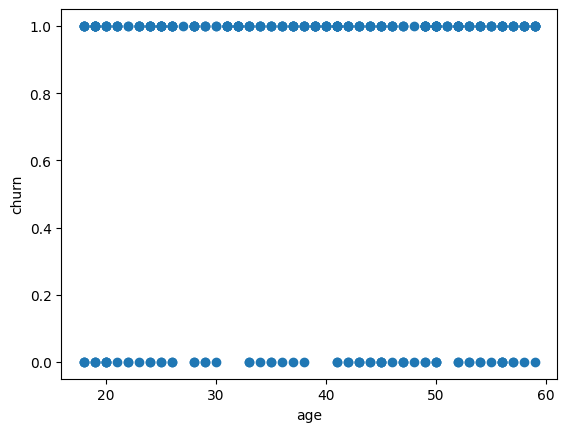

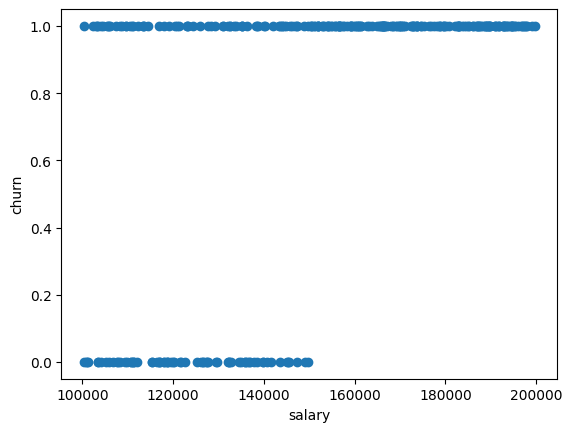

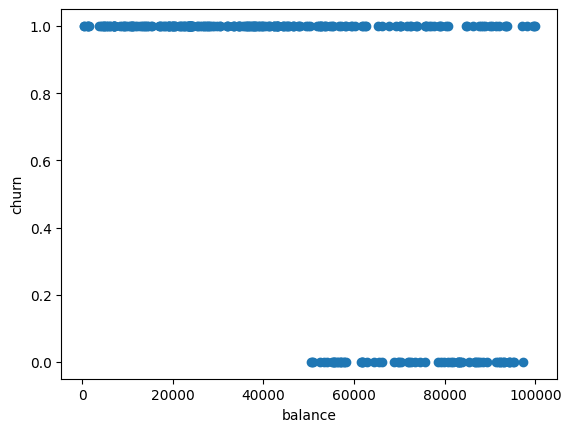

In [ ]:
features = ["age", "salary","balance"]
for col in features:
    plt.figure()
    plt.scatter(data[col], data["churn"])
    plt.xlabel(col)
    plt.ylabel("churn")
    plt.show

In [ ]:
x= data[["age", "salary", "balance"]]
y= data["churn"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model= LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 0.9166666666666666


In [ ]:
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred))

confusion_matrix:
 [[16  3]
 [ 2 39]]


In [ ]:
print("classification report:\n" , classification_report(y_test, y_pred))

classification report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86        19
           1       0.93      0.95      0.94        41

    accuracy                           0.92        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.92      0.92      0.92        60



In [ ]:
print("roc_auc_score:", roc_auc_score(y_test, y_pred))

roc_auc_score: 0.8966623876765083


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
np.random.seed(42)

data = pd.DataFrame({
    "hours_studied": np.random.randint(1, 10, 50),
    "attendance": np.random.randint(50, 100, 50)
})

data.head()

,hours_studied,attendance
0,7,53
1,4,51
2,8,55
3,5,91
4,7,53


In [ ]:
X = data[["hours_studied", "attendance"]]

model = KMeans(n_clusters=3, random_state=42, n_init=10)
data["cluster"] = model.fit_predict(X)

data.head()

,hours_studied,attendance,cluster
0,7,53,1
1,4,51,1
2,8,55,1
3,5,91,0
4,7,53,1


In [ ]:
score = silhouette_score(X, data["cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.5276411515754762


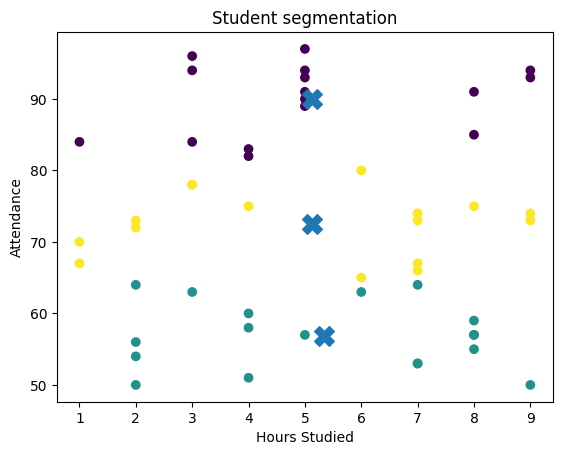

In [ ]:
plt.scatter(data["hours_studied"], data["attendance"], c=data["cluster"])
centers = model.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student segmentation")
plt.show()

In [77]:
# Example: New student
# hours studied = 6, attendance = 80
new_student = [[6, 80]]
predicted_cluster = model.predict(new_student)
print("new student belongs to cluster:", predicted_cluster[0])

new student belongs to cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [78]:
data.groupby("cluster").mean()

,hours_studied,attendance
cluster,,
0,5.125000,90.000000
1,5.333333,56.888889
2,5.125000,72.500000
